# Mini-Project: Loan Status Prediction
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Binary classification on mixed categorical and numeric loan application data using SVM.

Main goals:

- Handle missing values across both numeric and categorical columns.
- Encode categorical features and scale numeric features.
- Use a stratified split and train an SVM classifier.
- Evaluate with the full metric set.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Load the Dataset

In [2]:
url = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/refs/heads/main/dataset/loan_status_data.csv'

df = pd.read_csv(url)
print('Shape:', df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Missing Values

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
missing = df.isnull().sum()
print(missing[missing > 0])

Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


In [5]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'Loan_ID' in categorical_cols:
    categorical_cols.remove('Loan_ID')
    df = df.drop('Loan_ID', axis=1)

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values after filling:', df.isnull().sum().sum())

Missing values after filling: 0


## EDA

In [6]:
print(df['Loan_Status'].value_counts())
print(f'Approval rate: {(df["Loan_Status"]=="Y").mean()*100:.1f}%')

Loan_Status
Y    422
N    192
Name: count, dtype: int64
Approval rate: 68.7%


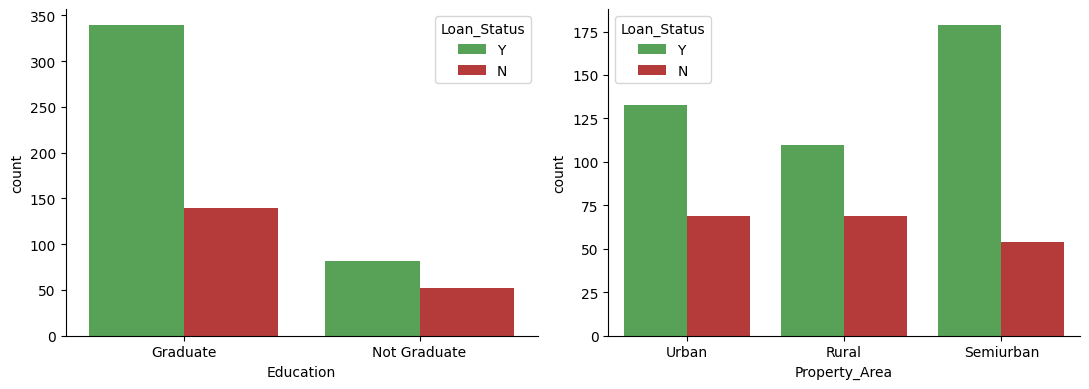

Education
Graduate        0.708
Not Graduate    0.612
Name: Loan_Status, dtype: float64
Property_Area
Rural        0.615
Semiurban    0.768
Urban        0.658
Name: Loan_Status, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='Education', hue='Loan_Status', data=df, ax=axes[0],
              palette={'Y': '#2CA02C', 'N': '#C00000'}, alpha=0.85)
sns.countplot(x='Property_Area', hue='Loan_Status', data=df, ax=axes[1],
              palette={'Y': '#2CA02C', 'N': '#C00000'}, alpha=0.85)
plt.tight_layout()
plt.show()

print(df.groupby('Education')['Loan_Status'].apply(lambda x: (x=='Y').mean()).round(3))
print(df.groupby('Property_Area')['Loan_Status'].apply(lambda x: (x=='Y').mean()).round(3))

**Observation:**
Graduate applicants and Semiurban applicants both show a higher approval rate than the other categories within their respective columns.

## Encoding

In [8]:
df_encoded = df.copy()
encoders = {}

for col in categorical_cols + ['Loan_Status']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## Train-Test Split and Scaling

In [9]:
X = df_encoded.drop('Loan_Status', axis=1)
y = df_encoded['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}  Test: {X_test_scaled.shape}')
print(f'Train approval rate: {y_train.mean():.3f}  Test approval rate: {y_test.mean():.3f}')

Train: (491, 11)  Test: (123, 11)
Train approval rate: 0.686  Test approval rate: 0.691


## Training the SVM Classifier

In [10]:
model = SVC(kernel='rbf', C=1)
model.fit(X_train_scaled, y_train)

train_preds = model.predict(X_train_scaled)
test_preds = model.predict(X_test_scaled)

print(f'Train accuracy: {accuracy_score(y_train, train_preds):.4f}')
print(f'Test accuracy:  {accuracy_score(y_test, test_preds):.4f}')

Train accuracy: 0.8167
Test accuracy:  0.8537


## Evaluation

In [11]:
print(f'Precision: {precision_score(y_test, test_preds):.4f}')
print(f'Recall:    {recall_score(y_test, test_preds):.4f}')
print(f'F1:        {f1_score(y_test, test_preds):.4f}')
print()
print(classification_report(y_test, test_preds, target_names=['Rejected', 'Approved']))

Precision: 0.8317
Recall:    0.9882
F1:        0.9032

              precision    recall  f1-score   support

    Rejected       0.95      0.55      0.70        38
    Approved       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



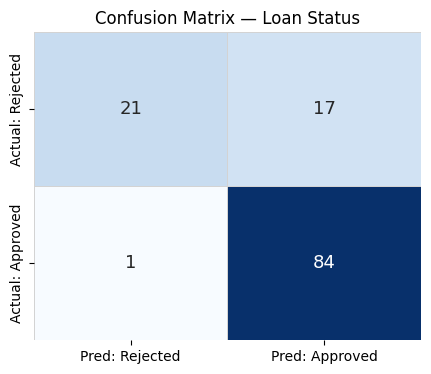

In [12]:
cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Rejected', 'Pred: Approved'],
            yticklabels=['Actual: Rejected', 'Actual: Approved'],
            linewidths=0.5, linecolor='lightgray', cbar=False, annot_kws={'size': 13})
ax.set_title('Confusion Matrix — Loan Status')
plt.show()

**Observation:**
Most errors fall on the rejected class being predicted as approved — consistent with the approval-rate imbalance in the training data, the model leans toward the majority outcome at the decision boundary.

## Linear vs RBF Kernel Comparison

In [13]:
for kernel in ['linear', 'rbf']:
    m = SVC(kernel=kernel, C=1).fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_scaled))
    print(f'{kernel:8s} kernel test accuracy: {acc:.4f}')

linear   kernel test accuracy: 0.8537
rbf      kernel test accuracy: 0.8537


**Observation:**
Linear and RBF perform similarly here, suggesting the decision boundary doesn't need much curvature to separate the classes on this feature set.